# Black Grouse 2030 Land-Use Scenario Project

## Stage 3: Observed Land-Use Change

This notebook analyses observed land-use transitions between:

- 1990 and 2012
- 2012 and 2024
- 1990 and 2024

The analysis uses the harmonised 25 m land-use rasters created in Stage 2.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

print("Packages imported successfully.")

Packages imported successfully.


In [3]:
PROJECT_DIR = Path.cwd()

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

HARMONISED_RASTERS = {
    1990: PROCESSED_DIR / "HGN1990_harmonised_25m.tif",
    2012: PROCESSED_DIR / "LGN7_2012_harmonised_25m.tif",
    2024: PROCESSED_DIR / "LGN2024_harmonised_25m.tif",
}

CLASS_NAMES = {
    1: "Agricultural matrix",
    2: "Core habitat",
    3: "Forest",
    4: "Urban and infrastructure",
    5: "Water",
}

for year, raster_path in HARMONISED_RASTERS.items():

    status = "FOUND" if raster_path.exists() else "MISSING"

    print(f"{year}: {status}")
    print(raster_path)

1990: FOUND
C:\Users\smit1\BlackGrouse_2030\data\processed\HGN1990_harmonised_25m.tif
2012: FOUND
C:\Users\smit1\BlackGrouse_2030\data\processed\LGN7_2012_harmonised_25m.tif
2024: FOUND
C:\Users\smit1\BlackGrouse_2030\data\processed\LGN2024_harmonised_25m.tif


In [4]:
landuse_arrays = {}
raster_profiles = {}

for year, raster_path in HARMONISED_RASTERS.items():

    with rasterio.open(raster_path) as src:

        landuse_arrays[year] = src.read(1)
        raster_profiles[year] = src.profile.copy()

        print(f"\nYear: {year}")
        print(f"Shape: {landuse_arrays[year].shape}")
        print(f"CRS: {src.crs}")
        print(f"Resolution: {src.res}")
        print(
            "Classes:",
            sorted(
                np.unique(
                    landuse_arrays[year][
                        landuse_arrays[year] != 0
                    ]
                ).astype(int).tolist()
            ),
        )


reference_shape = landuse_arrays[1990].shape
reference_transform = raster_profiles[1990]["transform"]
reference_crs = raster_profiles[1990]["crs"]

for year in [2012, 2024]:

    if landuse_arrays[year].shape != reference_shape:
        raise ValueError(
            f"The {year} raster has a different shape."
        )

    if raster_profiles[year]["transform"] != reference_transform:
        raise ValueError(
            f"The {year} raster has a different transform."
        )

    if raster_profiles[year]["crs"] != reference_crs:
        raise ValueError(
            f"The {year} raster has a different CRS."
        )


print("\nAll three rasters are aligned and ready for change analysis.")


Year: 1990
Shape: (1592, 1023)
CRS: EPSG:28992
Resolution: (25.0, 25.0)
Classes: [1, 2, 3, 4, 5]

Year: 2012
Shape: (1592, 1023)
CRS: EPSG:28992
Resolution: (25.0, 25.0)
Classes: [1, 2, 3, 4, 5]

Year: 2024
Shape: (1592, 1023)
CRS: EPSG:28992
Resolution: (25.0, 25.0)
Classes: [1, 2, 3, 4, 5]

All three rasters are aligned and ready for change analysis.


In [5]:
PIXEL_AREA_KM2 = (25 * 25) / 1_000_000

CHANGE_PERIODS = {
    "1990_2012": (1990, 2012),
    "2012_2024": (2012, 2024),
    "1990_2024": (1990, 2024),
}


def calculate_transition_table(
    start_array,
    end_array,
    start_year,
    end_year,
):
    """
    Calculate transitions between two harmonised land-use rasters.
    """

    valid_mask = (
        (start_array != 0)
        & (end_array != 0)
    )

    start_valid = start_array[valid_mask]
    end_valid = end_array[valid_mask]

    records = []

    for start_class in range(1, 6):

        starting_class_pixels = int(
            np.sum(start_valid == start_class)
        )

        for end_class in range(1, 6):

            transition_pixels = int(
                np.sum(
                    (start_valid == start_class)
                    & (end_valid == end_class)
                )
            )

            if starting_class_pixels > 0:
                percentage_of_start_class = (
                    transition_pixels
                    / starting_class_pixels
                    * 100
                )
            else:
                percentage_of_start_class = 0

            records.append(
                {
                    "start_year": start_year,
                    "end_year": end_year,
                    "from_class": start_class,
                    "from_class_name": CLASS_NAMES[start_class],
                    "to_class": end_class,
                    "to_class_name": CLASS_NAMES[end_class],
                    "pixel_count": transition_pixels,
                    "area_km2": round(
                        transition_pixels
                        * PIXEL_AREA_KM2,
                        2,
                    ),
                    "percentage_of_start_class": round(
                        percentage_of_start_class,
                        2,
                    ),
                    "unchanged": start_class == end_class,
                }
            )

    return pd.DataFrame(records)

In [6]:
transition_tables = {}

for period_name, (start_year, end_year) in CHANGE_PERIODS.items():

    transition_table = calculate_transition_table(
        start_array=landuse_arrays[start_year],
        end_array=landuse_arrays[end_year],
        start_year=start_year,
        end_year=end_year,
    )

    transition_tables[period_name] = transition_table

    output_path = (
        TABLES_DIR
        / f"landuse_transitions_{period_name}.csv"
    )

    transition_table.to_csv(
        output_path,
        index=False,
    )

    print(f"\nTransition table: {start_year}–{end_year}")
    print(
        transition_table[
            transition_table["pixel_count"] > 0
        ].to_string(index=False)
    )

    print(f"\nSaved: {output_path}")


Transition table: 1990–2012
 start_year  end_year  from_class          from_class_name  to_class            to_class_name  pixel_count  area_km2  percentage_of_start_class  unchanged
       1990      2012           1      Agricultural matrix         1      Agricultural matrix       746587    466.62                      87.30       True
       1990      2012           1      Agricultural matrix         2             Core habitat        25483     15.93                       2.98      False
       1990      2012           1      Agricultural matrix         3                   Forest        14632      9.14                       1.71      False
       1990      2012           1      Agricultural matrix         4 Urban and infrastructure        63283     39.55                       7.40      False
       1990      2012           1      Agricultural matrix         5                    Water         5230      3.27                       0.61      False
       1990      2012           2        

In [7]:
area_records = []

for year, raster_data in landuse_arrays.items():

    valid_data = raster_data[raster_data != 0]
    total_pixels = len(valid_data)

    values, counts = np.unique(
        valid_data,
        return_counts=True,
    )

    for class_value, pixel_count in zip(values, counts):

        area_records.append(
            {
                "year": year,
                "class_value": int(class_value),
                "class_name": CLASS_NAMES[int(class_value)],
                "pixel_count": int(pixel_count),
                "area_km2": pixel_count * PIXEL_AREA_KM2,
                "percentage": pixel_count / total_pixels * 100,
            }
        )


landuse_area_by_year = pd.DataFrame(area_records)

landuse_area_by_year["area_km2"] = (
    landuse_area_by_year["area_km2"].round(2)
)

landuse_area_by_year["percentage"] = (
    landuse_area_by_year["percentage"].round(2)
)


AREA_BY_YEAR_OUTPUT = (
    TABLES_DIR / "landuse_area_by_year.csv"
)

landuse_area_by_year.to_csv(
    AREA_BY_YEAR_OUTPUT,
    index=False,
)

display(landuse_area_by_year)

print("\nSaved:")
print(AREA_BY_YEAR_OUTPUT)

,year,class_value,class_name,pixel_count,area_km2,percentage
0,1990,1,Agricultural matrix,855215,534.51,70.07
1,1990,2,Core habitat,34420,21.51,2.82
2,1990,3,Forest,243747,152.34,19.97
3,1990,4,Urban and infrastructure,78946,49.34,6.47
4,1990,5,Water,8272,5.17,0.68
5,2012,1,Agricultural matrix,766060,478.79,62.76
6,2012,2,Core habitat,68403,42.75,5.60
7,2012,3,Forest,233509,145.94,19.13
8,2012,4,Urban and infrastructure,139106,86.94,11.40
9,2012,5,Water,13522,8.45,1.11



Saved:
C:\Users\smit1\BlackGrouse_2030\outputs\tables\landuse_area_by_year.csv


In [8]:
net_change_records = []

for period_name, (start_year, end_year) in CHANGE_PERIODS.items():

    number_of_years = end_year - start_year

    for class_value in range(1, 6):

        start_pixels = int(
            np.sum(
                landuse_arrays[start_year] == class_value
            )
        )

        end_pixels = int(
            np.sum(
                landuse_arrays[end_year] == class_value
            )
        )

        start_area_km2 = (
            start_pixels * PIXEL_AREA_KM2
        )

        end_area_km2 = (
            end_pixels * PIXEL_AREA_KM2
        )

        net_change_km2 = (
            end_area_km2 - start_area_km2
        )

        if start_area_km2 > 0:
            percentage_change = (
                net_change_km2
                / start_area_km2
                * 100
            )
        else:
            percentage_change = np.nan

        annual_change_km2 = (
            net_change_km2 / number_of_years
        )

        net_change_records.append(
            {
                "period": period_name,
                "start_year": start_year,
                "end_year": end_year,
                "class_value": class_value,
                "class_name": CLASS_NAMES[class_value],
                "start_area_km2": round(
                    start_area_km2,
                    2,
                ),
                "end_area_km2": round(
                    end_area_km2,
                    2,
                ),
                "net_change_km2": round(
                    net_change_km2,
                    2,
                ),
                "percentage_change": round(
                    percentage_change,
                    2,
                ),
                "annual_change_km2": round(
                    annual_change_km2,
                    3,
                ),
            }
        )


net_landuse_change = pd.DataFrame(
    net_change_records
)

NET_CHANGE_OUTPUT = (
    TABLES_DIR / "net_landuse_change.csv"
)

net_landuse_change.to_csv(
    NET_CHANGE_OUTPUT,
    index=False,
)

display(net_landuse_change)

print("\nSaved:")
print(NET_CHANGE_OUTPUT)

,period,start_year,end_year,class_value,class_name,start_area_km2,end_area_km2,net_change_km2,percentage_change,annual_change_km2
0,1990_2012,1990,2012,1,Agricultural matrix,534.51,478.79,-55.72,-10.42,-2.533
1,1990_2012,1990,2012,2,Core habitat,21.51,42.75,21.24,98.73,0.965
2,1990_2012,1990,2012,3,Forest,152.34,145.94,-6.40,-4.20,-0.291
3,1990_2012,1990,2012,4,Urban and infrastructure,49.34,86.94,37.60,76.20,1.709
4,1990_2012,1990,2012,5,Water,5.17,8.45,3.28,63.47,0.149
5,2012_2024,2012,2024,1,Agricultural matrix,478.79,456.27,-22.52,-4.70,-1.877
6,2012_2024,2012,2024,2,Core habitat,42.75,54.41,11.66,27.26,0.971
7,2012_2024,2012,2024,3,Forest,145.94,138.67,-7.27,-4.98,-0.606
8,2012_2024,2012,2024,4,Urban and infrastructure,86.94,101.74,14.80,17.02,1.233
9,2012_2024,2012,2024,5,Water,8.45,11.79,3.34,39.51,0.278



Saved:
C:\Users\smit1\BlackGrouse_2030\outputs\tables\net_landuse_change.csv


In [9]:
core_habitat_change_records = []

for period_name, (start_year, end_year) in CHANGE_PERIODS.items():

    start_array = landuse_arrays[start_year]
    end_array = landuse_arrays[end_year]

    valid_mask = (
        (start_array != 0)
        & (end_array != 0)
    )

    start_habitat = (
        (start_array == 2)
        & valid_mask
    )

    end_habitat = (
        (end_array == 2)
        & valid_mask
    )

    persistent_pixels = int(
        np.sum(start_habitat & end_habitat)
    )

    loss_pixels = int(
        np.sum(start_habitat & ~end_habitat)
    )

    gain_pixels = int(
        np.sum(~start_habitat & end_habitat)
    )

    start_habitat_pixels = int(
        np.sum(start_habitat)
    )

    end_habitat_pixels = int(
        np.sum(end_habitat)
    )

    core_habitat_change_records.append(
        {
            "period": period_name,
            "start_year": start_year,
            "end_year": end_year,
            "start_habitat_km2": round(
                start_habitat_pixels * PIXEL_AREA_KM2,
                2,
            ),
            "persistent_habitat_km2": round(
                persistent_pixels * PIXEL_AREA_KM2,
                2,
            ),
            "habitat_loss_km2": round(
                loss_pixels * PIXEL_AREA_KM2,
                2,
            ),
            "habitat_gain_km2": round(
                gain_pixels * PIXEL_AREA_KM2,
                2,
            ),
            "end_habitat_km2": round(
                end_habitat_pixels * PIXEL_AREA_KM2,
                2,
            ),
            "net_change_km2": round(
                (
                    gain_pixels - loss_pixels
                )
                * PIXEL_AREA_KM2,
                2,
            ),
            "persistence_percentage": round(
                persistent_pixels
                / start_habitat_pixels
                * 100,
                2,
            ),
            "loss_percentage": round(
                loss_pixels
                / start_habitat_pixels
                * 100,
                2,
            ),
            "new_habitat_percentage": round(
                gain_pixels
                / end_habitat_pixels
                * 100,
                2,
            ),
        }
    )


core_habitat_change = pd.DataFrame(
    core_habitat_change_records
)

CORE_HABITAT_CHANGE_OUTPUT = (
    TABLES_DIR / "core_habitat_change_summary.csv"
)

core_habitat_change.to_csv(
    CORE_HABITAT_CHANGE_OUTPUT,
    index=False,
)

display(core_habitat_change)

print("\nSaved:")
print(CORE_HABITAT_CHANGE_OUTPUT)

,period,start_year,end_year,start_habitat_km2,persistent_habitat_km2,habitat_loss_km2,habitat_gain_km2,end_habitat_km2,net_change_km2,persistence_percentage,loss_percentage,new_habitat_percentage
0,1990_2012,1990,2012,21.51,19.00,2.51,23.75,42.75,21.24,88.33,11.67,55.55
1,2012_2024,2012,2024,42.75,31.57,11.18,22.84,54.41,11.66,73.84,26.16,41.98
2,1990_2024,1990,2024,21.51,17.44,4.07,36.97,54.41,32.90,81.06,18.94,67.95



Saved:
C:\Users\smit1\BlackGrouse_2030\outputs\tables\core_habitat_change_summary.csv


In [10]:
CORE_CHANGE_CLASS_NAMES = {
    0: "Background",
    1: "Non-core habitat",
    2: "Persistent core habitat",
    3: "Core habitat loss",
    4: "Core habitat gain",
}

CORE_CHANGE_RASTERS = {}

for period_name, (start_year, end_year) in CHANGE_PERIODS.items():

    start_array = landuse_arrays[start_year]
    end_array = landuse_arrays[end_year]

    valid_mask = (
        (start_array != 0)
        & (end_array != 0)
    )

    start_habitat = start_array == 2
    end_habitat = end_array == 2

    change_array = np.zeros(
        start_array.shape,
        dtype=np.uint8,
    )

    # Valid pixels that are not persistent, lost, or gained habitat
    change_array[
        valid_mask
        & ~start_habitat
        & ~end_habitat
    ] = 1

    # Core habitat present in both years
    change_array[
        valid_mask
        & start_habitat
        & end_habitat
    ] = 2

    # Core habitat present initially but absent later
    change_array[
        valid_mask
        & start_habitat
        & ~end_habitat
    ] = 3

    # Core habitat absent initially but present later
    change_array[
        valid_mask
        & ~start_habitat
        & end_habitat
    ] = 4

    output_path = (
        PROCESSED_DIR
        / f"core_habitat_change_{period_name}.tif"
    )

    output_profile = raster_profiles[start_year].copy()

    output_profile.update(
        {
            "driver": "GTiff",
            "dtype": "uint8",
            "count": 1,
            "nodata": 0,
            "compress": "lzw",
        }
    )

    with rasterio.open(
        output_path,
        "w",
        **output_profile,
    ) as destination:
        destination.write(change_array, 1)

    CORE_CHANGE_RASTERS[period_name] = output_path

    values, counts = np.unique(
        change_array[change_array != 0],
        return_counts=True,
    )

    print(f"\nCore-habitat change raster: {start_year}–{end_year}")

    for class_value, pixel_count in zip(values, counts):

        print(
            f"{CORE_CHANGE_CLASS_NAMES[int(class_value)]}: "
            f"{pixel_count * PIXEL_AREA_KM2:.2f} km²"
        )

    print(f"Saved: {output_path}")


Core-habitat change raster: 1990–2012
Non-core habitat: 717.61 km²
Persistent core habitat: 19.00 km²
Core habitat loss: 2.51 km²
Core habitat gain: 23.75 km²
Saved: C:\Users\smit1\BlackGrouse_2030\data\processed\core_habitat_change_1990_2012.tif

Core-habitat change raster: 2012–2024
Non-core habitat: 697.28 km²
Persistent core habitat: 31.57 km²
Core habitat loss: 11.18 km²
Core habitat gain: 22.84 km²
Saved: C:\Users\smit1\BlackGrouse_2030\data\processed\core_habitat_change_2012_2024.tif

Core-habitat change raster: 1990–2024
Non-core habitat: 704.39 km²
Persistent core habitat: 17.44 km²
Core habitat loss: 4.07 km²
Core habitat gain: 36.97 km²
Saved: C:\Users\smit1\BlackGrouse_2030\data\processed\core_habitat_change_1990_2024.tif


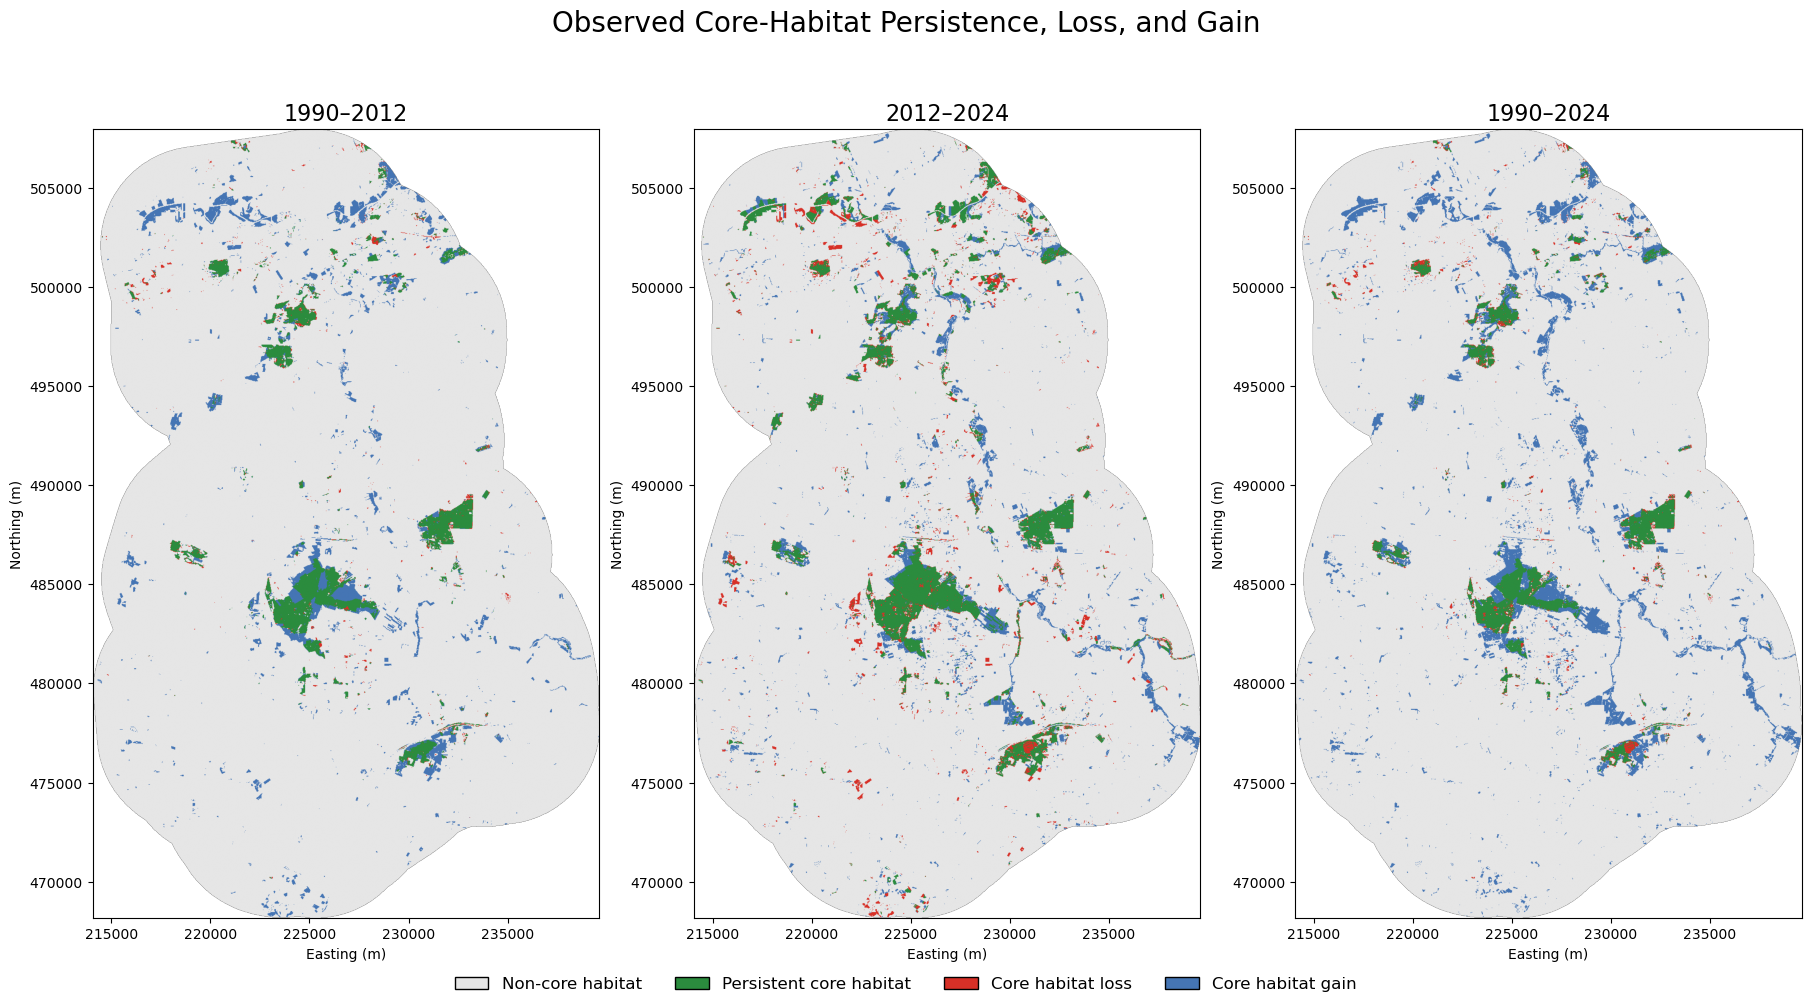

Figure saved:
C:\Users\smit1\BlackGrouse_2030\outputs\figures\core_habitat_change_1990_2012_2024.png


In [11]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch


CORE_CHANGE_COLOURS = {
    1: "#e6e6e6",
    2: "#2b8c3e",
    3: "#d73027",
    4: "#4575b4",
}

CORE_CHANGE_LABELS = {
    1: "Non-core habitat",
    2: "Persistent core habitat",
    3: "Core habitat loss",
    4: "Core habitat gain",
}

PERIOD_LABELS = {
    "1990_2012": "1990–2012",
    "2012_2024": "2012–2024",
    "1990_2024": "1990–2024",
}


change_colormap = ListedColormap(
    [
        CORE_CHANGE_COLOURS[class_value]
        for class_value in range(1, 5)
    ]
)

change_norm = BoundaryNorm(
    boundaries=[0.5, 1.5, 2.5, 3.5, 4.5],
    ncolors=change_colormap.N,
)


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 10),
    constrained_layout=True,
)


for axis, (period_name, raster_path) in zip(
    axes,
    CORE_CHANGE_RASTERS.items(),
):

    with rasterio.open(raster_path) as src:

        change_data = src.read(1)

        raster_extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ]

    masked_change_data = np.ma.masked_where(
        change_data == 0,
        change_data,
    )

    axis.imshow(
        masked_change_data,
        cmap=change_colormap,
        norm=change_norm,
        extent=raster_extent,
        origin="upper",
    )

    axis.set_title(
        PERIOD_LABELS[period_name],
        fontsize=16,
    )

    axis.set_xlabel("Easting (m)")
    axis.set_ylabel("Northing (m)")
    axis.set_aspect("equal")


legend_items = [
    Patch(
        facecolor=CORE_CHANGE_COLOURS[class_value],
        edgecolor="black",
        label=CORE_CHANGE_LABELS[class_value],
    )
    for class_value in range(1, 5)
]


fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=12,
)

fig.suptitle(
    "Observed Core-Habitat Persistence, Loss, and Gain",
    fontsize=20,
)


CORE_CHANGE_FIGURE_OUTPUT = (
    FIGURES_DIR
    / "core_habitat_change_1990_2012_2024.png"
)

plt.savefig(
    CORE_CHANGE_FIGURE_OUTPUT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Figure saved:")
print(CORE_CHANGE_FIGURE_OUTPUT)

In [12]:
core_transition_records = []

for period_name, transition_table in transition_tables.items():

    start_year = int(transition_table["start_year"].iloc[0])
    end_year = int(transition_table["end_year"].iloc[0])

    # New core habitat: other classes converted to class 2
    habitat_gains = transition_table[
        (transition_table["to_class"] == 2)
        & (transition_table["from_class"] != 2)
    ]

    for _, row in habitat_gains.iterrows():

        core_transition_records.append(
            {
                "period": period_name,
                "start_year": start_year,
                "end_year": end_year,
                "change_type": "Core habitat gain",
                "source_or_destination_class": row["from_class"],
                "source_or_destination_name": row["from_class_name"],
                "pixel_count": int(row["pixel_count"]),
                "area_km2": row["area_km2"],
            }
        )

    # Core-habitat loss: class 2 converted to other classes
    habitat_losses = transition_table[
        (transition_table["from_class"] == 2)
        & (transition_table["to_class"] != 2)
    ]

    for _, row in habitat_losses.iterrows():

        core_transition_records.append(
            {
                "period": period_name,
                "start_year": start_year,
                "end_year": end_year,
                "change_type": "Core habitat loss",
                "source_or_destination_class": row["to_class"],
                "source_or_destination_name": row["to_class_name"],
                "pixel_count": int(row["pixel_count"]),
                "area_km2": row["area_km2"],
            }
        )


core_habitat_transition_sources = pd.DataFrame(
    core_transition_records
)

CORE_TRANSITION_OUTPUT = (
    TABLES_DIR
    / "core_habitat_gain_and_loss_transitions.csv"
)

core_habitat_transition_sources.to_csv(
    CORE_TRANSITION_OUTPUT,
    index=False,
)

print(
    core_habitat_transition_sources.to_string(
        index=False
    )
)

print("\nSaved:")
print(CORE_TRANSITION_OUTPUT)

   period  start_year  end_year       change_type  source_or_destination_class source_or_destination_name  pixel_count  area_km2
1990_2012        1990      2012 Core habitat gain                            1        Agricultural matrix        25483     15.93
1990_2012        1990      2012 Core habitat gain                            3                     Forest        12335      7.71
1990_2012        1990      2012 Core habitat gain                            4   Urban and infrastructure           90      0.06
1990_2012        1990      2012 Core habitat gain                            5                      Water           93      0.06
1990_2012        1990      2012 Core habitat loss                            1        Agricultural matrix          195      0.12
1990_2012        1990      2012 Core habitat loss                            3                     Forest         3373      2.11
1990_2012        1990      2012 Core habitat loss                            4   Urban and infras

In [13]:
change_extent_records = []

for period_name, (start_year, end_year) in CHANGE_PERIODS.items():

    start_array = landuse_arrays[start_year]
    end_array = landuse_arrays[end_year]

    valid_mask = (
        (start_array != 0)
        & (end_array != 0)
    )

    unchanged_pixels = int(
        np.sum(
            (start_array == end_array)
            & valid_mask
        )
    )

    changed_pixels = int(
        np.sum(
            (start_array != end_array)
            & valid_mask
        )
    )

    total_pixels = int(
        np.sum(valid_mask)
    )

    change_extent_records.append(
        {
            "period": period_name,
            "start_year": start_year,
            "end_year": end_year,
            "total_area_km2": round(
                total_pixels * PIXEL_AREA_KM2,
                2,
            ),
            "unchanged_area_km2": round(
                unchanged_pixels * PIXEL_AREA_KM2,
                2,
            ),
            "changed_area_km2": round(
                changed_pixels * PIXEL_AREA_KM2,
                2,
            ),
            "unchanged_percentage": round(
                unchanged_pixels / total_pixels * 100,
                2,
            ),
            "changed_percentage": round(
                changed_pixels / total_pixels * 100,
                2,
            ),
        }
    )


landuse_change_extent = pd.DataFrame(
    change_extent_records
)

CHANGE_EXTENT_OUTPUT = (
    TABLES_DIR / "landuse_change_extent_summary.csv"
)

landuse_change_extent.to_csv(
    CHANGE_EXTENT_OUTPUT,
    index=False,
)

display(landuse_change_extent)

print("\nSaved:")
print(CHANGE_EXTENT_OUTPUT)

,period,start_year,end_year,total_area_km2,unchanged_area_km2,changed_area_km2,unchanged_percentage,changed_percentage
0,1990_2012,1990,2012,762.88,663.48,99.39,86.97,13.03
1,2012_2024,2012,2024,762.88,670.92,91.95,87.95,12.05
2,1990_2024,1990,2024,762.88,636.45,126.43,83.43,16.57



Saved:
C:\Users\smit1\BlackGrouse_2030\outputs\tables\landuse_change_extent_summary.csv


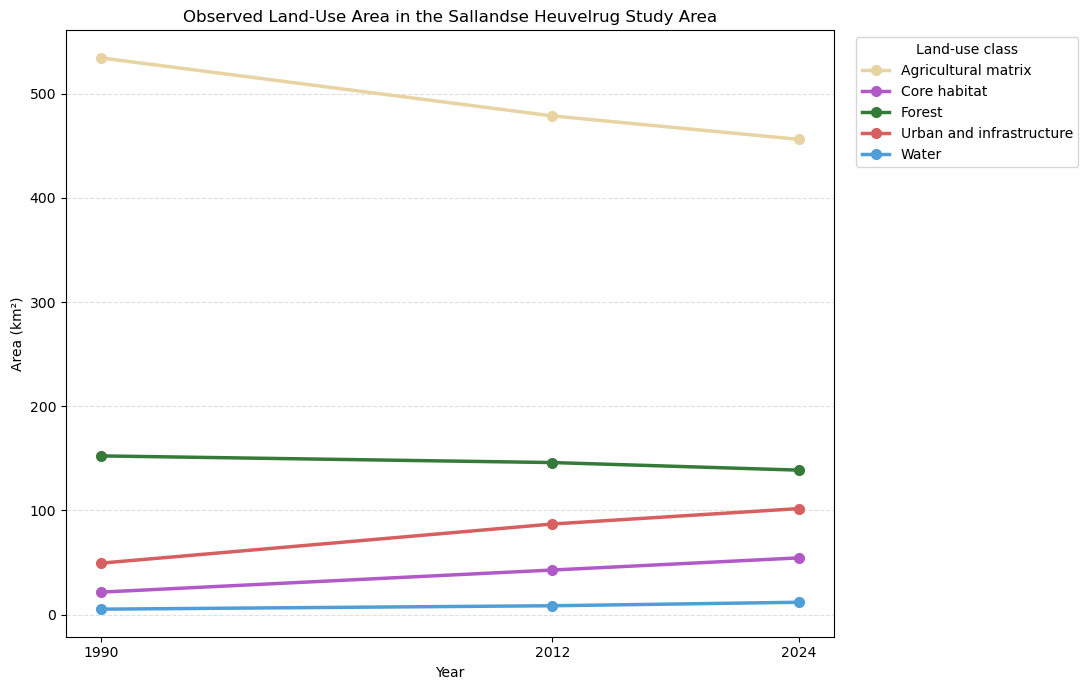

Figure saved:
C:\Users\smit1\BlackGrouse_2030\outputs\figures\observed_landuse_area_1990_2012_2024.png


In [14]:
CLASS_COLOURS = {
    "Agricultural matrix": "#e8d4a2",
    "Core habitat": "#b15ac7",
    "Forest": "#357a38",
    "Urban and infrastructure": "#d65f5f",
    "Water": "#4f9ed8",
}


fig, ax = plt.subplots(figsize=(11, 7))

for class_name in CLASS_NAMES.values():

    class_data = landuse_area_by_year[
        landuse_area_by_year["class_name"] == class_name
    ].sort_values("year")

    ax.plot(
        class_data["year"],
        class_data["area_km2"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=class_name,
        color=CLASS_COLOURS[class_name],
    )


ax.set_title(
    "Observed Land-Use Area in the Sallandse Heuvelrug Study Area"
)

ax.set_xlabel("Year")
ax.set_ylabel("Area (km²)")

ax.set_xticks([1990, 2012, 2024])

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

ax.legend(
    title="Land-use class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()


LANDUSE_AREA_FIGURE_OUTPUT = (
    FIGURES_DIR / "observed_landuse_area_1990_2012_2024.png"
)

plt.savefig(
    LANDUSE_AREA_FIGURE_OUTPUT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Figure saved:")
print(LANDUSE_AREA_FIGURE_OUTPUT)